In [1]:
import os

In [2]:
os.chdir('../')

In [3]:
%pwd

'c:\\Users\\hulkh\\Desktop\\Python\\supplier_clustering\\Supplier_clustering'

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('artifacts/feature_engineering/engineered_data.csv')
df

,supplier_id,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
0,SUP-001,0.972818,0.090826,2180952.04,107,0.121495,0.009346,0.934579,0.121495
1,SUP-002,0.970539,0.089811,83912380.83,4172,0.257910,0.014621,0.891419,0.257910
2,SUP-003,1.090915,0.088498,10388962.85,456,0.370614,0.017544,0.868421,0.370614
3,SUP-004,1.051534,0.084760,1426125.23,67,0.208955,0.000000,0.910448,0.208955
4,SUP-005,1.099693,0.082324,2972062.85,127,0.330709,0.007874,0.874016,0.330709
...,...,...,...,...,...,...,...,...,...
101,SUP-102,0.908411,0.060653,5689957.03,710,0.239437,0.023944,0.911268,0.239437
102,SUP-103,1.071268,0.063343,1482987.60,156,0.384615,0.012821,0.858974,0.384615
103,SUP-104,1.056981,0.054959,188833.89,21,0.047619,0.000000,0.952381,0.047619
104,SUP-105,1.079207,0.064942,6606243.68,708,0.237288,0.008475,0.895480,0.237288


In [6]:
df.describe()

,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
count,106.000000,106.000000,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000
mean,0.993467,0.080349,3.879088e+06,444.603774,0.862463,0.017964,0.836586,0.862463
std,0.066226,0.036096,9.194998e+06,798.817873,2.406002,0.027652,0.203117,2.406002
min,0.860772,0.014846,1.638747e+04,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.942912,0.053354,1.387961e+05,37.250000,0.205151,0.000000,0.869916,0.205151
50%,1.002002,0.065603,8.974078e+05,127.500000,0.261013,0.011528,0.893593,0.261013
75%,1.044056,0.111058,4.492715e+06,539.750000,0.332677,0.019713,0.902629,0.332677
max,1.161405,0.185699,8.391238e+07,5384.000000,11.005181,0.160000,1.000000,11.005181


In [7]:
skewness = df.skew(numeric_only=True)
skewness

price_competitiveness    -0.083209
cost_variability          0.707082
total_spend               6.635875
order_frequency           3.717419
average_delivery_delay    3.864803
quality_rejection_rate    3.011462
on_time_delivery_rate    -3.445044
average_late_days         3.864803
dtype: float64

In [9]:
feature_columns = [
    "price_competitiveness",
    "cost_variability",
    "total_spend",
    "order_frequency",
    "average_late_days",
    "average_delivery_delay",
    "quality_rejection_rate",
    "on_time_delivery_rate"
]

df1 = df[feature_columns]
supplier_ids = df["supplier_id"]

In [10]:
corr = df1.corr()
corr

,price_competitiveness,cost_variability,total_spend,order_frequency,average_late_days,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate
price_competitiveness,1.000000,-0.042901,0.059236,0.055424,-0.065270,-0.065270,-0.005787,0.054397
cost_variability,-0.042901,1.000000,0.184900,0.032602,0.475892,0.475892,0.507433,-0.464426
total_spend,0.059236,0.184900,1.000000,0.728739,0.009069,0.009069,0.051369,0.005467
order_frequency,0.055424,0.032602,0.728739,1.000000,0.024518,0.024518,0.078642,0.000081
average_late_days,-0.065270,0.475892,0.009069,0.024518,1.000000,1.000000,0.874685,-0.973648
average_delivery_delay,-0.065270,0.475892,0.009069,0.024518,1.000000,1.000000,0.874685,-0.973648
quality_rejection_rate,-0.005787,0.507433,0.051369,0.078642,0.874685,0.874685,1.000000,-0.834632
on_time_delivery_rate,0.054397,-0.464426,0.005467,0.000081,-0.973648,-0.973648,-0.834632,1.000000


In [11]:
for col in df1.columns:

    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df1[
        (df1[col] < lower_bound) |
        (df1[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


price_competitiveness
Lower bound: 0.7911948803990645
Upper bound: 1.1957727544315195
Number of outliers: 0

cost_variability
Lower bound: -0.03320159186912794
Upper bound: 0.19761338617506435
Number of outliers: 0

total_spend
Lower bound: -6392081.924999999
Upper bound: 11023592.895
Number of outliers: 11

order_frequency
Lower bound: -716.5
Upper bound: 1293.5
Number of outliers: 10

average_late_days
Lower bound: 0.013862820291935224
Upper bound: 0.5239657723917679
Number of outliers: 16

average_delivery_delay
Lower bound: 0.013862820291935224
Upper bound: 0.5239657723917679
Number of outliers: 16

quality_rejection_rate
Lower bound: -0.0295700187969924
Upper bound: 0.049283364661654
Number of outliers: 7

on_time_delivery_rate
Lower bound: 0.8208463881334005
Upper bound: 0.9516982825172637
Number of outliers: 20


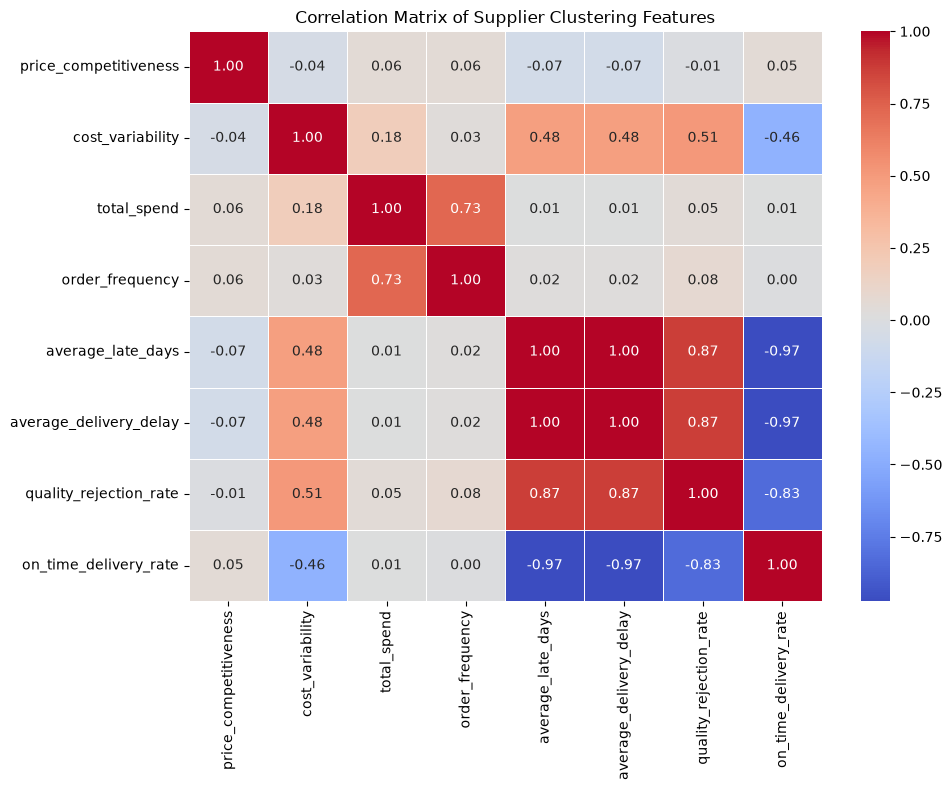

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Supplier Clustering Features")
plt.tight_layout()
plt.show()

| Feature                  | Outliers |   Skewness | What it tells us                             |
| ------------------------ | -------: | ---------: | -------------------------------------------- |
| `price_competitiveness`  |        0 |     -0.083 | Very well behaved                            |
| `cost_variability`       |        0 |      0.707 | Moderately right-skewed, but no IQR outliers |
| `total_spend`            |       11 |  **6.636** | Extremely right-skewed                       |
| `order_frequency`        |       10 |  **3.717** | Strongly right-skewed                        |
| `average_delivery_delay` |       16 |  **3.865** | Strongly right-skewed                        |
| `quality_rejection_rate` |        7 |  **3.011** | Strongly right-skewed                        |
| `on_time_delivery_rate`  |       20 | **-3.445** | Strongly left-skewed                         |
| `average_late_days`      |       16 |  **3.865** | Strongly right-skewed                        |

In [ ]:
results = df1[["supplier_id"]].copy()

results["cluster"] = kmeans.labels_